# human

cv

In [ ]:
# pnu_cv_pnu_train_pn_eval.py
import os
import json
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, LeaveOneOut, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, matthews_corrcoef, f1_score,
    roc_curve, precision_recall_curve
)

import torch

from PNU_mlp import MLP, pnpu_risk, predict_proba


# -----------------------------
# 固定配置
# -----------------------------
SPECIE = "human"
TISSUE = "heart"

if SPECIE == 'mouse':
    cv = LeaveOneOut()
    layer_size = (256, 32)
    # PNU 超参
    PI = 0.2
    GAMMA = 0.25  # PNU 混合权重：0->更像PN，1->更像PU（建议 0.25/0.5/0.75 做敏感性）
    BETA = 0.0
else:
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    layer_size = (128, 64)
    # PNU 超参
    PI = 0.1
    GAMMA = 0.5  # PNU 混合权重：0->更像PN，1->更像PU（建议 0.25/0.5/0.75 做敏感性）
    BETA = 0.0

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EMB_CSV = f"../../HinSAGE/{SPECIE}/lncRNA_embeddings_{TISSUE}.csv"
POS_CSV = f"../../data/benchmark/{SPECIE}/ess_lnc.csv"
NEG_CSV = f"../../data/benchmark/{SPECIE}/noness_lnc.csv"   # 训练 + 评估 都会用到（PNU 需要 N）

OUT_DIR = f"./pnu_train_pn_eval_{SPECIE}"

# MLP 结构
DROPOUT = 0.0

LR = 0.005
WEIGHT_DECAY = 0.001
EPOCHS = 200
BATCH_SIZE = 512


# early stopping（在 train 内切 val）
VAL_RATIO_IN_TRAIN = 0.15
PATIENCE = 15

class PNU_BatchSampler(torch.utils.data.Sampler):
    """
    Make each batch contain P, N, U.
    s: +1 (P), -1 (N), 0 (U)
    """
    def __init__(self, s_np, batch_size, bP=16, bN=16, drop_last=True, seed=42):
        self.s = np.asarray(s_np).astype(np.int64)
        self.batch_size = int(batch_size)
        self.bP = int(bP)
        self.bN = int(bN)
        self.bU = int(batch_size) - self.bP - self.bN
        if self.bU <= 0:
            raise ValueError("bP + bN must be < batch_size")
        self.drop_last = drop_last
        self.rng = np.random.default_rng(seed)

        self.idxP = np.where(self.s == 1)[0]
        self.idxN = np.where(self.s == -1)[0]
        self.idxU = np.where(self.s == 0)[0]

        # 如果某一类在该fold训练集中为空，就无法强制三类batch
        self.valid = (len(self.idxP) > 0 and len(self.idxN) > 0 and len(self.idxU) > 0)

        # 估算 batch 数：按“主导类”来决定迭代长度，避免太短
        if self.valid:
            # 用 U 的规模作为 epoch 的参考（也可以换成 max 三者）
            self.num_batches = len(self.idxU) // self.bU
            if not self.drop_last and len(self.idxU) % self.bU != 0:
                self.num_batches += 1
            self.num_batches = max(self.num_batches, 1)
        else:
            # fallback：和普通 DataLoader 类似
            self.num_batches = len(self.s) // self.batch_size
            if not self.drop_last and len(self.s) % self.batch_size != 0:
                self.num_batches += 1
            self.num_batches = max(self.num_batches, 1)

    def __iter__(self):
        if not self.valid:
            # fallback：普通随机打乱
            idx_all = np.arange(len(self.s))
            self.rng.shuffle(idx_all)
            for i in range(self.num_batches):
                b = idx_all[i*self.batch_size:(i+1)*self.batch_size]
                if len(b) == 0:
                    continue
                yield b.tolist()
            return

        for _ in range(self.num_batches):
            # 有放回采样，保证每类够用
            p = self.rng.choice(self.idxP, size=self.bP, replace=(len(self.idxP) < self.bP))
            n = self.rng.choice(self.idxN, size=self.bN, replace=(len(self.idxN) < self.bN))
            u = self.rng.choice(self.idxU, size=self.bU, replace=(len(self.idxU) < self.bU))
            batch = np.concatenate([p, n, u])
            self.rng.shuffle(batch)
            yield batch.tolist()

    def __len__(self):
        return self.num_batches



# -----------------------------
def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_embeddings(emb_csv: str):
    df = pd.read_csv(emb_csv, header=None)
    ids = df.iloc[:, 0].astype(str).str.strip().values
    X = df.iloc[:, 1:].values.astype(np.float32)
    return ids, X


def load_id_set(csv_path: str, col="lncRNA_id"):
    df = pd.read_csv(csv_path)
    if col not in df.columns:
        raise ValueError(f"{csv_path} 必须包含列 {col}")
    return set(df[col].astype(str).str.strip().values)


def compute_pn_metrics(y_true01: np.ndarray, scores: np.ndarray):
    roc = roc_auc_score(y_true01, scores) if len(np.unique(y_true01)) > 1 else float("nan")
    pr = average_precision_score(y_true01, scores) if len(np.unique(y_true01)) > 1 else float("nan")
    return {"ROC_AUC": float(roc), "PR_AUC": float(pr)}


def compute_threshold_metrics(y_true01: np.ndarray, scores: np.ndarray, thresh: float = 0.5):
    """
    用固定阈值(默认0.5)把分数转为类别，计算：
    Sen(Recall+), Spe, Acc, PPV, F1, MCC，以及 TP/FP/TN/FN
    """
    y_true01 = np.asarray(y_true01).astype(int)
    scores = np.asarray(scores).astype(float)

    y_pred01 = (scores >= thresh).astype(int)

    # confusion_matrix 保证顺序是 [[TN, FP],[FN, TP]]
    tn, fp, fn, tp = confusion_matrix(y_true01, y_pred01, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    acc  = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    # sklearn 的 f1_score / mcc 对极端情况更稳，但仍给你显式值
    f1  = f1_score(y_true01, y_pred01, zero_division=0)
    mcc = matthews_corrcoef(y_true01, y_pred01) if len(np.unique(y_true01)) > 1 else float("nan")

    return {
        "threshold": float(thresh),
        "Sensitivity": float(sens),
        "Specificity": float(spec),
        "Accuracy": float(acc),
        "PPV": float(ppv),
        "F1": float(f1),
        "MCC": float(mcc),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
    }



def train_pnu_one_split(X_tr, s_tr, X_val, s_val, seed_offset=0):
    """
    PNU 训练：
    s in {+1, -1, 0}  (P=+1, N=-1, U=0)
    """
    set_seed(SEED + seed_offset)

    model = MLP(in_dim=X_tr.shape[1], hidden_dims=layer_size, dropout=DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    xb = torch.tensor(X_tr, dtype=torch.float32)
    sb = torch.tensor(s_tr, dtype=torch.int64)
    dataset = torch.utils.data.TensorDataset(xb, sb)
    loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    best_val = -1.0
    best_state = None
    bad = 0

    for ep in range(1, EPOCHS + 1):
        model.train()
        for xb_batch, sb_batch in loader:
            xb_batch = xb_batch.to(DEVICE)
            sb_batch = sb_batch.to(DEVICE)
            logits = model(xb_batch).squeeze(-1)

            loss = pnpu_risk(logits, sb_batch, pi=PI, gamma=GAMMA, beta=BETA)

            opt.zero_grad()
            loss.backward()
            opt.step()

        # -------- early stopping：优先用 val 的 PN 子集 PR-AUC --------
        scores_val = predict_proba(model, X_val, device=DEVICE)

        mask_pn = (s_val != 0)
        if np.any(mask_pn):
            y_val_pn = (s_val[mask_pn] == 1).astype(int)   # P=1, N=0
            sc_val_pn = scores_val[mask_pn]
            if len(np.unique(y_val_pn)) > 1:
                val_pr = average_precision_score(y_val_pn, sc_val_pn)
            else:
                val_pr = 0.0
        else:
            # 极端退化情况：val 里没有 N，只有 P/U
            y_val_proxy = (s_val == 1).astype(int)
            if len(np.unique(y_val_proxy)) > 1:
                val_pr = average_precision_score(y_val_proxy, scores_val)
            else:
                val_pr = 0.0

        if val_pr > best_val + 1e-4:
            best_val = val_pr
            bad = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


def main():
    os.makedirs(OUT_DIR, exist_ok=True)
    set_seed(SEED)

    ids, X = load_embeddings(EMB_CSV)
    pos_set = load_id_set(POS_CSV)
    neg_set = load_id_set(NEG_CSV)

    # 训练用 PNU 标签：+1(P), -1(N), 0(U)
    s = np.zeros(len(ids), dtype=np.int64)
    for i, _id in enumerate(ids):
        if _id in pos_set:
            s[i] = 1
        elif _id in neg_set:
            s[i] = -1
        else:
            s[i] = 0

    # 评估用 PN：只挑出 P ∪ N 的样本
    pn_mask = (s != 0)
    pn_ids = ids[pn_mask]
    pn_y = (s[pn_mask] == 1).astype(np.int64)  # P=1, N=0

    pn_oof_scores = np.full(len(pn_ids), np.nan, dtype=np.float64)

    pn_indices_global = np.where(pn_mask)[0]
    pn_indices_local = np.arange(len(pn_indices_global))

    print(f"[All] total={len(ids)} | P={(s==1).sum()} | N={(s==-1).sum()} | U={(s==0).sum()} | dim={X.shape[1]}")
    print(f"[PN eval set] size={len(pn_ids)} | P={int(pn_y.sum())} | N={int((pn_y==0).sum())}")
    print(f"[Config] PI={PI} GAMMA={GAMMA} hidden={layer_size} lr={LR} wd={WEIGHT_DECAY} epochs={EPOCHS}")
    print(f"TopK for {SPECIE}: {TOPK_LIST}")
    print("Train uses P+N+U (PNU). Metrics computed on PN only (OOF).")

    for fold, (pn_trloc, pn_teloc) in enumerate(cv.split(pn_indices_local, pn_y), start=1):
        # 该折 PN-test 在全体中的下标
        te_global_idx = pn_indices_global[pn_teloc]

        # ---- 训练数据：全体 - 该折 PN-test（避免泄露）----
        train_mask = np.ones(len(ids), dtype=bool)
        train_mask[te_global_idx] = False

        X_tr_full = X[train_mask]
        s_tr_full = s[train_mask]

        # val 切分：对 (P,N,U) 三类分层
        strat = (s_tr_full + 1)  # {-1,0,1} -> {0,1,2}
        tr2_idx, val_idx = train_test_split(
            np.arange(len(X_tr_full)),
            test_size=VAL_RATIO_IN_TRAIN,
            random_state=SEED + fold,
            stratify=strat,
        )
        X_tr, s_tr = X_tr_full[tr2_idx], s_tr_full[tr2_idx]
        X_val, s_val = X_tr_full[val_idx], s_tr_full[val_idx]

        # ---- scaler：只 fit 在 X_tr ----
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr).astype(np.float32)
        X_val = scaler.transform(X_val).astype(np.float32)

        # 该折 PN-test
        X_te_pn = scaler.transform(X[te_global_idx]).astype(np.float32)
        y_te_pn = (s[te_global_idx] == 1).astype(np.int64)

        # ---- 训练 PNU ----
        model = train_pnu_one_split(X_tr, s_tr, X_val, s_val, seed_offset=fold)

        # ---- 预测并算 PN 指标 ----
        scores_te = predict_proba(model, X_te_pn, device=DEVICE)
        pn_oof_scores[pn_teloc] = scores_te

        met = compute_pn_metrics(y_te_pn, scores_te)

        row = {"fold": fold}
        row.update({k: met[k] for k in ["ROC_AUC", "PR_AUC"]})

        # LOO 下折内可能 NaN，这里照样打印
        print(f"[Fold {fold}] PN ROC={met['ROC_AUC']:.4f} PR={met['PR_AUC']:.4f}")

    # ---- OOF 汇总（PN）----
    ok = ~np.isnan(pn_oof_scores)
    pn_oof_scores2 = pn_oof_scores[ok]
    pn_y2 = pn_y[ok]

    # ---- Save OOF ROC curve (FPR, TPR) ----
    fpr, tpr, _ = roc_curve(pn_y2, pn_oof_scores2)
    pd.DataFrame({"FPR": fpr, "TPR": tpr}).to_csv(
        os.path.join(OUT_DIR, f"oof_roc_curve_PN_{TISSUE}.csv"),
        index=False
    )

    # ---- Save OOF PR curve (Recall, Precision) ----
    precision, recall, _ = precision_recall_curve(pn_y2, pn_oof_scores2)
    pd.DataFrame({"Recall": recall, "Precision": precision}).to_csv(
        os.path.join(OUT_DIR, f"oof_pr_curve_PN_{TISSUE}.csv"),
        index=False
    )


    met_oof = compute_pn_metrics(pn_y2, pn_oof_scores2)
    thr_oof = compute_threshold_metrics(pn_y2, pn_oof_scores2, thresh=0.35)

    # 保存 summary
    summary = {
        "SPECIE": SPECIE,
        "N_all": int(len(ids)),
        "P_all": int((s == 1).sum()),
        "N_all_neg": int((s == -1).sum()),
        "U_all": int((s == 0).sum()),
        "PN_size": int(len(pn_y)),
        "PN_P": int(pn_y.sum()),
        "PN_N": int((pn_y == 0).sum()),
        "Train": "PNU (P+N+U), with fold-wise PN-test exclusion to avoid leakage",
        "pi": PI,
        "gamma": GAMMA,
        "hidden_dims": list(layer_size),
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "OOF_on_PN": {
            "ROC_AUC": met_oof["ROC_AUC"],
            "PR_AUC": met_oof["PR_AUC"],
            "threadhold_metric": {
                    "threshold": thr_oof["threshold"],
                    "Sensitivity": thr_oof["Sensitivity"],
                    "Specificity": thr_oof["Specificity"],
                    "Accuracy": thr_oof["Accuracy"],
                    "PPV": thr_oof["PPV"],
                    "F1": thr_oof["F1"],
                    "MCC": thr_oof["MCC"],
                    "P": thr_oof["TP"]+thr_oof["FP"],
                },
        },
    }

    with open(os.path.join(OUT_DIR, f"cv_oof_summary_PN_{TISSUE}.json"), "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    # 保存 PN OOF 分数
    pd.DataFrame({"lncRNA_id": pn_ids[ok], "y_true": pn_y2, "score_oof": pn_oof_scores2}).to_csv(
        os.path.join(OUT_DIR, f"pnu_scores_oof_PN_{TISSUE}.csv"), index=False
    )

    print("\n[OOF Summary on PN]")
    print(f"ROC_AUC: {met_oof['ROC_AUC']:.4f}")
    print(f"PR_AUC : {met_oof['PR_AUC']:.4f}")
    print(f"\nSaved to: {OUT_DIR}")


if __name__ == "__main__":
    main()


pi

In [ ]:
# pnu_pi_sensitivity.py
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, LeaveOneOut, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

import torch
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.family'] = ['Times New Roman','SimSun']

from PNU_mlp import MLP, pnpu_risk, predict_proba

# -----------------------------
# Config
# -----------------------------
SPECIE = "human"
TISSUE = "heart"

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# π sensitivity list
PI_LIST = [0.3,0.4]

# PNU hyper (fixed; only PI changes)
BETA = 0.0
if SPECIE == "mouse":
    cv = LeaveOneOut()
    layer_size = (256, 32)
    GAMMA = 0.25
else:
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    layer_size = (128, 64)
    GAMMA = 0.5

EMB_CSV = f"../../HinSAGE/{SPECIE}/lncRNA_embeddings_{TISSUE}.csv"
POS_CSV = f"../../data/benchmark/{SPECIE}/ess_lnc.csv"
NEG_CSV = f"../../data/benchmark/{SPECIE}/noness_lnc.csv"

OUT_DIR = f"./pnu_pi_sensitivity_{SPECIE}"
os.makedirs(OUT_DIR, exist_ok=True)

# Train config
DROPOUT = 0.0
LR = 0.005
WEIGHT_DECAY = 0.001
EPOCHS = 200
BATCH_SIZE = 512
VAL_RATIO_IN_TRAIN = 0.15
PATIENCE = 15


# -----------------------------
# Utils
# -----------------------------
def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_embeddings(emb_csv: str):
    df = pd.read_csv(emb_csv, header=None)
    ids = df.iloc[:, 0].astype(str).str.strip().values
    X = df.iloc[:, 1:].values.astype(np.float32)
    return ids, X


def load_id_set(csv_path: str, col="lncRNA_id"):
    df = pd.read_csv(csv_path)
    if col not in df.columns:
        raise ValueError(f"{csv_path} 必须包含列 {col}")
    return set(df[col].astype(str).str.strip().values)


def train_pnu_one_split(X_tr, s_tr, X_val, s_val, pi: float, seed_offset=0):
    """
    PNU(PNPU) training, with early stopping on val PN-subset PR-AUC.
    s: +1(P), -1(N), 0(U)
    """
    set_seed(SEED + seed_offset)

    model = MLP(in_dim=X_tr.shape[1], hidden_dims=layer_size, dropout=DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    xb = torch.tensor(X_tr, dtype=torch.float32)
    sb = torch.tensor(s_tr, dtype=torch.int64)
    dataset = torch.utils.data.TensorDataset(xb, sb)
    loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

    best_val = -1.0
    best_state = None
    bad = 0

    for ep in range(1, EPOCHS + 1):
        model.train()
        for xb_batch, sb_batch in loader:
            xb_batch = xb_batch.to(DEVICE)
            sb_batch = sb_batch.to(DEVICE)

            logits = model(xb_batch).squeeze(-1)
            loss = pnpu_risk(logits, sb_batch, pi=pi, gamma=GAMMA, beta=BETA)

            opt.zero_grad()
            loss.backward()
            opt.step()

        # ---- early stopping metric: PR-AUC on val PN subset ----
        scores_val = predict_proba(model, X_val, device=DEVICE)
        mask_pn = (s_val != 0)

        if np.any(mask_pn):
            y_val_pn = (s_val[mask_pn] == 1).astype(int)  # P=1, N=0
            sc_val_pn = scores_val[mask_pn]
            if len(np.unique(y_val_pn)) > 1:
                val_pr = average_precision_score(y_val_pn, sc_val_pn)
            else:
                val_pr = 0.0
        else:
            # degenerate fallback: proxy P vs (U/N) if needed
            y_val_proxy = (s_val == 1).astype(int)
            if len(np.unique(y_val_proxy)) > 1:
                val_pr = average_precision_score(y_val_proxy, scores_val)
            else:
                val_pr = 0.0

        if val_pr > best_val + 1e-4:
            best_val = val_pr
            bad = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


def run_one_pi(pi: float, ids: np.ndarray, X: np.ndarray, s: np.ndarray, pn_mask: np.ndarray):
    """
    CV on PN subset (for evaluation) + fold-wise exclusion to avoid leakage.
    Returns OOF scores on PN, plus curve points & AUCs.
    """
    pn_ids = ids[pn_mask]
    pn_y = (s[pn_mask] == 1).astype(np.int64)  # P=1, N=0

    pn_oof_scores = np.full(len(pn_ids), np.nan, dtype=np.float64)

    pn_indices_global = np.where(pn_mask)[0]
    pn_indices_local = np.arange(len(pn_indices_global))

    for fold, (_, pn_teloc) in enumerate(cv.split(pn_indices_local, pn_y), start=1):
        te_global_idx = pn_indices_global[pn_teloc]

        # training set excludes PN-test fold to avoid leakage
        train_mask = np.ones(len(ids), dtype=bool)
        train_mask[te_global_idx] = False

        X_tr_full = X[train_mask]
        s_tr_full = s[train_mask]

        # split train -> train/val (stratify by P/N/U)
        strat = (s_tr_full + 1)  # {-1,0,1}->{0,1,2}
        tr2_idx, val_idx = train_test_split(
            np.arange(len(X_tr_full)),
            test_size=VAL_RATIO_IN_TRAIN,
            random_state=SEED + fold,
            stratify=strat,
        )
        X_tr, s_tr = X_tr_full[tr2_idx], s_tr_full[tr2_idx]
        X_val, s_val = X_tr_full[val_idx], s_tr_full[val_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr).astype(np.float32)
        X_val = scaler.transform(X_val).astype(np.float32)

        X_te_pn = scaler.transform(X[te_global_idx]).astype(np.float32)

        model = train_pnu_one_split(X_tr, s_tr, X_val, s_val, pi=pi, seed_offset=fold)
        scores_te = predict_proba(model, X_te_pn, device=DEVICE)

        pn_oof_scores[pn_teloc] = scores_te

    ok = ~np.isnan(pn_oof_scores)
    pn_oof_scores2 = pn_oof_scores[ok]
    pn_y2 = pn_y[ok]
    pn_ids2 = pn_ids[ok]

    # curves + auc
    roc_auc = roc_auc_score(pn_y2, pn_oof_scores2) if len(np.unique(pn_y2)) > 1 else float("nan")
    pr_auc = average_precision_score(pn_y2, pn_oof_scores2) if len(np.unique(pn_y2)) > 1 else float("nan")

    fpr, tpr, _ = roc_curve(pn_y2, pn_oof_scores2)
    precision, recall, _ = precision_recall_curve(pn_y2, pn_oof_scores2)

    return {
        "pi": float(pi),
        "pn_ids": pn_ids2,
        "pn_y": pn_y2,
        "pn_oof_scores": pn_oof_scores2,
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "fpr": fpr,
        "tpr": tpr,
        "precision": precision,
        "recall": recall,
    }


def main():
    set_seed(SEED)

    ids, X = load_embeddings(EMB_CSV)
    pos_set = load_id_set(POS_CSV)
    neg_set = load_id_set(NEG_CSV)

    # s: +1(P), -1(N), 0(U)
    s = np.zeros(len(ids), dtype=np.int64)
    for i, _id in enumerate(ids):
        if _id in pos_set:
            s[i] = 1
        elif _id in neg_set:
            s[i] = -1
        else:
            s[i] = 0

    pn_mask = (s != 0)

    print(f"[All] total={len(ids)} | P={(s==1).sum()} | N={(s==-1).sum()} | U={(s==0).sum()} | dim={X.shape[1]}")
    print(f"[Config] specie={SPECIE} tissue={TISSUE} gamma={GAMMA} beta={BETA} hidden={layer_size}")
    print(f"[PI_LIST] {PI_LIST}")
    print("Running PI sensitivity...")

    results = []
    for pi in PI_LIST:
        print(f"\n--- PI = {pi:.2f} ---")
        res = run_one_pi(pi, ids, X, s, pn_mask)
        results.append(res)

        # save per-pi oof scores
        out_scores = pd.DataFrame({
            "lncRNA_id": res["pn_ids"],
            "y_true": res["pn_y"],
            "score_oof": res["pn_oof_scores"],
        })
        out_scores.to_csv(os.path.join(OUT_DIR, f"pnu_scores_oof_PN_{TISSUE}_pi{pi:.2f}.csv"), index=False)

        # save per-pi curves (optional)
        pd.DataFrame({"FPR": res["fpr"], "TPR": res["tpr"]}).to_csv(
            os.path.join(OUT_DIR, f"oof_roc_curve_PN_{TISSUE}_pi{pi:.2f}.csv"), index=False
        )
        pd.DataFrame({"Recall": res["recall"], "Precision": res["precision"]}).to_csv(
            os.path.join(OUT_DIR, f"oof_pr_curve_PN_{TISSUE}_pi{pi:.2f}.csv"), index=False
        )

        print(f"OOF ROC_AUC={res['roc_auc']:.4f} | PR_AUC={res['pr_auc']:.4f}")



if __name__ == "__main__":
    main()


plot pi

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.metrics import auc

rcParams['font.family'] = ['Times New Roman', 'SimSun']
# 全局字体大小设置
rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 14
rcParams['axes.labelsize'] = 12
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['legend.fontsize'] = 12

# -----------------------------
# Config
# -----------------------------
SPECIE = "human"
TISSUE = "heart"
PI_LIST = [0.10, 0.20, 0.30, 0.40]

COLORS = ["#e2edc9", "#a4dcb7", "#65c4b9", "#607bbc"]

BASE_DIR = f"./pnu_pi_sensitivity_{SPECIE}"

# =============================
# ROC
# =============================
plt.figure(figsize=(5, 4))

for i, pi in enumerate(PI_LIST):
    roc_path = os.path.join(
        BASE_DIR,
        f"oof_roc_curve_PN_{TISSUE}_pi{pi:.2f}.csv"
    )

    if not os.path.exists(roc_path):
        print(f"Missing ROC file: {roc_path}")
        continue

    df = pd.read_csv(roc_path)
    roc_auc = auc(df["FPR"], df["TPR"])

    plt.plot(
        df["FPR"],
        df["TPR"],
        color=COLORS[i],
        linewidth=1.5,
        label=rf"$\pi$={pi:.2f} (AUC={roc_auc:.3f})"

    )

plt.xlabel("假阳率")
plt.ylabel("真阳率")
plt.title("ROC曲线（人类）")
plt.legend()
plt.tight_layout()

roc_svg = os.path.join(BASE_DIR, f"pi_sensitivity_ROC_{SPECIE}_{TISSUE}.svg")
plt.savefig(roc_svg, format="svg")
plt.close()

print(f"Saved ROC SVG: {roc_svg}")

# =============================
# PR
# =============================
plt.figure(figsize=[5,4])

for i, pi in enumerate(PI_LIST):
    pr_path = os.path.join(
        BASE_DIR,
        f"oof_pr_curve_PN_{TISSUE}_pi{pi:.2f}.csv"
    )

    if not os.path.exists(pr_path):
        print(f"Missing PR file: {pr_path}")
        continue

    df = pd.read_csv(pr_path)
    pr_auc = auc(df["Recall"], df["Precision"])

    plt.plot(
        df["Recall"],
        df["Precision"],
        color=COLORS[i],
        linewidth=1.5,
        label=rf"$\pi$={pi:.2f} (AUPR={pr_auc:.3f})"

    )

plt.xlabel("召回率")
plt.ylabel("精确度")
plt.title("PR曲线（人类）")
plt.legend(loc='lower left')
plt.tight_layout()

pr_svg = os.path.join(BASE_DIR, f"pi_sensitivity_PR_{SPECIE}_{TISSUE}.svg")
plt.savefig(pr_svg, format="svg")
plt.close()

print(f"Saved PR SVG: {pr_svg}")
print("Done.")


final

In [ ]:
# final_train_score_topk.py
import os
import json
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

import torch

from PNU_mlp import MLP, pnpu_risk, pn_risk, predict_proba


# -----------------------------
# 配置
# -----------------------------
SPECIE = "human"
TISSUE = "heart"

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EMB_CSV = f"../../HinSAGE/{SPECIE}/lncRNA_embeddings_{TISSUE}.csv"
POS_CSV = f"../../data/benchmark/{SPECIE}/ess_lnc.csv"
NEG_CSV = f"../../data/benchmark/{SPECIE}/noness_lnc.csv"

OUT_DIR = f"./final_train_score_{SPECIE}"

# 选择训练模式：
# - "PNU": 用 P+N+U 训练（pnpu_risk）
# - "PN" : 只用 P+N 训练（pn_risk）
MODE = "PNU"

# PNU超参（MODE="PNU" 时有效）
if SPECIE == 'human':
    PI = 0.1
    GAMMA = 0.5
    BETA = 0.0
else:
    PI = 0.1
    GAMMA = 0.25
    BETA = 0.0

# 模型
HIDDEN_DIMS = (128, 64) if SPECIE == "human" else (256, 32)
DROPOUT = 0.0

# 训练
LR = 0.005
WEIGHT_DECAY = 0.001
EPOCHS = 200
BATCH_SIZE = 512

# TopK
TOPK_LIST = (100, 500, 1000, 2000) if SPECIE == "human" else (100, 200, 500)


# -----------------------------
def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_embeddings(emb_csv: str):
    df = pd.read_csv(emb_csv, header=None)
    ids = df.iloc[:, 0].astype(str).str.strip().values
    X = df.iloc[:, 1:].values.astype(np.float32)
    return ids, X


def load_id_set(csv_path: str, col="lncRNA_id"):
    df = pd.read_csv(csv_path)
    if col not in df.columns:
        raise ValueError(f"{csv_path} 必须包含列 {col}")
    return set(df[col].astype(str).str.strip().values)


def compute_topk_metrics(scores: np.ndarray, y_true01: np.ndarray, topk_list):
    """
    在全体节点排序，计算：
    - P@K = hit/K
    - R@K = hit/P_total
    - Enrichment@K = P@K / base_rate，其中 base_rate = P_total / N_total
    注意：这里 y_true01=1 表示“已知正例”，其余全是0（未确认/负/未标记混在一起）
    """
    order = np.argsort(-scores)
    P_total = int(y_true01.sum())
    N_total = int(len(y_true01))
    base_rate = (P_total / float(N_total)) if N_total > 0 else 0.0

    out = {}
    for K in topk_list:
        K2 = min(int(K), N_total)
        hit = int(np.sum(y_true01[order[:K2]] == 1))
        prec = hit / float(K2) if K2 > 0 else 0.0
        rec = hit / float(P_total) if P_total > 0 else 0.0
        enr = (prec / base_rate) if base_rate > 0 else float("nan")
        out[K] = {
            "hit": hit,
            "P@K": float(prec),
            "R@K": float(rec),
            "E@K": float(enr),
        }
    return out


def train_final_model(X_all_sc: np.ndarray, s_all: np.ndarray):
    """
    用全体数据训练最终模型。
    MODE="PNU": 用 pnpu_risk(P+N+U)
    MODE="PN" : 用 pn_risk(只用P+N; U在训练中被忽略)
    """
    model = MLP(in_dim=X_all_sc.shape[1], hidden_dims=HIDDEN_DIMS, dropout=DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    xb = torch.tensor(X_all_sc, dtype=torch.float32)
    sb = torch.tensor(s_all, dtype=torch.int64)
    dataset = torch.utils.data.TensorDataset(xb, sb)
    loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

    for ep in range(1, EPOCHS + 1):
        model.train()
        for xb_batch, sb_batch in loader:
            xb_batch = xb_batch.to(DEVICE)
            sb_batch = sb_batch.to(DEVICE)

            logits = model(xb_batch).squeeze(-1)

            if MODE.upper() == "PNU":
                loss = pnpu_risk(logits, sb_batch, pi=PI, gamma=GAMMA, beta=BETA)
            elif MODE.upper() == "PN":
                loss = pn_risk(logits, sb_batch)  # pn_risk内部只用 P/N
            else:
                raise ValueError("MODE must be 'PNU' or 'PN'.")

            opt.zero_grad()
            loss.backward()
            opt.step()

    return model


def main():
    os.makedirs(OUT_DIR, exist_ok=True)
    set_seed(SEED)

    ids, X = load_embeddings(EMB_CSV)
    pos_set = load_id_set(POS_CSV)
    neg_set = load_id_set(NEG_CSV)

    # s: +1(P), -1(N), 0(U)
    s = np.zeros(len(ids), dtype=np.int64)
    for i, _id in enumerate(ids):
        if _id in pos_set:
            s[i] = 1
        elif _id in neg_set:
            s[i] = -1
        else:
            s[i] = 0

    print(f"[All] total={len(ids)} | P={(s==1).sum()} | N={(s==-1).sum()} | U={(s==0).sum()} | dim={X.shape[1]}")
    print(f"[Mode] {MODE} | hidden={HIDDEN_DIMS} lr={LR} wd={WEIGHT_DECAY} epochs={EPOCHS} bs={BATCH_SIZE}")
    if MODE.upper() == "PNU":
        print(f"[PNU params] PI={PI} GAMMA={GAMMA} BETA={BETA}")
    print(f"[TopK] {TOPK_LIST}")

    # scaler：fit on ALL
    scaler = StandardScaler()
    X_all_sc = scaler.fit_transform(X).astype(np.float32)

    # train
    model = train_final_model(X_all_sc, s)

    # score all
    scores_all = predict_proba(model, X_all_sc, device=DEVICE)

    # TopK：以“已知正例P”为命中标准（其余都当作未确认）
    y_all_proxy = (s == 1).astype(np.int64)
    topk = compute_topk_metrics(scores_all, y_all_proxy, TOPK_LIST)

    # save scores
    scores_path = os.path.join(OUT_DIR, f"final_scores_all_nodes_{MODE}_{TISSUE}.csv")
    pd.DataFrame({
        "lncRNA_id": ids,
        "s_obs": s,              # +1/-1/0
        "score_final": scores_all
    }).to_csv(scores_path, index=False)

    # save topk json
    topk_path = os.path.join(OUT_DIR, f"final_topk_all_nodes_{MODE}_{TISSUE}.json")
    with open(topk_path, "w", encoding="utf-8") as f:
        json.dump({str(K): topk[K] for K in TOPK_LIST}, f, ensure_ascii=False, indent=2)

    # save top candidates
    maxK = int(max(TOPK_LIST))
    order = np.argsort(-scores_all)
    top_idx = order[:maxK]
    cand_path = os.path.join(OUT_DIR, f"final_top{maxK}_candidates_{MODE}_{TISSUE}.csv")
    pd.DataFrame({
        "lncRNA_id": ids[top_idx],
        "score": scores_all[top_idx],
        "s_obs": s[top_idx],
    }).to_csv(cand_path, index=False)

    print("\n[Final TopK on ALL nodes | positives = known P only]")
    for K in TOPK_LIST:
        d = topk[K]
        print(f"  Top{K}: P@K={d['P@K']:.4f} R@K={d['R@K']:.4f} E@K={d['E@K']:.2f} (hit={d['hit']})")

    print(f"\nSaved:")
    print(f"  {scores_path}")
    print(f"  {topk_path}")
    print(f"  {cand_path}")


if __name__ == "__main__":
    main()


plot topk

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

csv_path = "topk_results_human.csv"
df = pd.read_csv(csv_path)

tissue_fullname = {
    "heart": "左心室",
    "lung": "左肺",
    "stomach": "胃"
}

color_map = {
    "SVM": "#607BBC",
    "MLP": "#65c4b9",
    "PNPU-MLP": "#a4dcb7"
}

k_values = [500, 1000, 2000]
x_pos = list(range(len(k_values)))  # 等距横坐标

out_dir = "./topk"
os.makedirs(out_dir, exist_ok=True)

def plot_one_metric(tissue: str, metric: str):
    """
    metric: 'precision' or 'recall'
    """
    tissue_df = df[df["tissue"] == tissue].copy()
    full_name = tissue_fullname.get(tissue, tissue)

    fig, ax = plt.subplots(figsize=(3.6, 2.6))

    # 为了稳定显示顺序（可选）
    clfs = [c for c in ["MLP", "SVM", "PNPU-MLP"] if c in tissue_df["clf"].unique()]
    # 如果有其他模型名也画出来
    for c in tissue_df["clf"].unique():
        if c not in clfs:
            clfs.append(c)

    for clf in clfs:
        row = tissue_df[tissue_df["clf"] == clf].iloc[0]
        if metric == "precision":
            y = [row[f"precision@{k}"] for k in k_values]
            title = f"Top-K 精确率（{full_name}）"
            ylabel = "精确率"
        else:
            y = [row[f"recall@{k}"] for k in k_values]
            title = f"Top-K 召回率（{full_name}）"
            ylabel = "召回率"

        ax.plot(
            x_pos, y,
            marker="o",
            linewidth=1.5,
            color=color_map.get(clf, None),
        )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("K")
    ax.set_xticks(x_pos, k_values)
    ax.grid(alpha=0.3)

    out_path = os.path.join(out_dir, f"human_{tissue}_{metric}.svg")
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")

from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import os

def save_legend_only():
    legend_order = ["SVM", "MLP", "PNPU-MLP"]

    handles = [
        Line2D([0], [0],
               color=color_map[name],
               lw=2,
               marker="o")
        for name in legend_order
    ]

    labels = legend_order

    # 画布宽一点，避免被压成一列
    fig = plt.figure(figsize=(6, 1.2))

    fig.legend(
        handles,
        labels,
        loc="center",
        ncol=len(labels),   # 关键：横向排列
        frameon=True,
        fontsize=12,
        handlelength=2.5,
        columnspacing=1.8
    )

    plt.axis("off")

    out_path = os.path.join(out_dir, "legend_only.svg")
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved legend-only: {out_path}")


# --- 逐组织输出：每个组织两张（precision / recall）---
for tissue in df["tissue"].unique():
    plot_one_metric(tissue, "precision")
    plot_one_metric(tissue, "recall")

# --- 单独输出 legend 图 ---
save_legend_only()

print("Done.")


Saved: ./topk\human_heart_precision.svg
Saved: ./topk\human_heart_recall.svg
Saved: ./topk\human_lung_precision.svg
Saved: ./topk\human_lung_recall.svg
Saved: ./topk\human_stomach_precision.svg
Saved: ./topk\human_stomach_recall.svg
Saved legend-only: ./topk\legend_only.svg
Done.


挑阈值

# 采样 mouse

cv

In [123]:
# pnu_cv_pnu_train_pn_eval.py
import os
import json
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, LeaveOneOut, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, matthews_corrcoef, f1_score,
    roc_curve, precision_recall_curve
)

import torch

from PNU_mlp import MLP, pnpu_risk, predict_proba


# -----------------------------
# 固定配置：你只改这里
# -----------------------------
SPECIE = "mouse"
TISSUE = "brain"

if SPECIE == 'mouse':
    cv = LeaveOneOut()
    layer_size = (256, 32)
    TOPK_LIST = (5, 10, 20)
    # PNU 超参
    PI = 0.2
    GAMMA = 0.25  # PNU 混合权重：0->更像PN，1->更像PU（建议 0.25/0.5/0.75 做敏感性）
    BETA = 0.0
else:
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    layer_size = (128, 64)
    TOPK_LIST = (100, 500, 1000, 2000)
    # PNU 超参
    PI = 0.1
    GAMMA = 0.5  # PNU 混合权重：0->更像PN，1->更像PU（建议 0.25/0.5/0.75 做敏感性）
    BETA = 0.0

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EMB_CSV = f"../../HinSAGE/{SPECIE}/lncRNA_embeddings_{TISSUE}.csv"
POS_CSV = f"../../data/benchmark/{SPECIE}/ess_lnc.csv"
NEG_CSV = f"../../data/benchmark/{SPECIE}/noness_lnc.csv"   # 训练 + 评估 都会用到（PNU 需要 N）

U_PER_EPOCH = 1000
RUN_TAG = f"U{U_PER_EPOCH}_epSubsample"   # 防覆盖用
OUT_DIR = f"./pnu_train_pn_eval_{SPECIE}_{RUN_TAG}"

# MLP 结构
DROPOUT = 0.0

LR = 0.005
WEIGHT_DECAY = 0.001
EPOCHS = 200
BATCH_SIZE = 512

# early stopping（在 train 内切 val）
VAL_RATIO_IN_TRAIN = 0.15
PATIENCE = 15

class PNU_BatchSampler(torch.utils.data.Sampler):
    """
    Make each batch contain P, N, U.
    s: +1 (P), -1 (N), 0 (U)
    """
    def __init__(self, s_np, batch_size, bP=16, bN=16, drop_last=True, seed=42):
        self.s = np.asarray(s_np).astype(np.int64)
        self.batch_size = int(batch_size)
        self.bP = int(bP)
        self.bN = int(bN)
        self.bU = int(batch_size) - self.bP - self.bN
        if self.bU <= 0:
            raise ValueError("bP + bN must be < batch_size")
        self.drop_last = drop_last
        self.rng = np.random.default_rng(seed)

        self.idxP = np.where(self.s == 1)[0]
        self.idxN = np.where(self.s == -1)[0]
        self.idxU = np.where(self.s == 0)[0]

        # 如果某一类在该fold训练集中为空，就无法强制三类batch
        self.valid = (len(self.idxP) > 0 and len(self.idxN) > 0 and len(self.idxU) > 0)

        # 估算 batch 数：按“主导类”来决定迭代长度，避免太短
        if self.valid:
            # 用 U 的规模作为 epoch 的参考（也可以换成 max 三者）
            self.num_batches = len(self.idxU) // self.bU
            if not self.drop_last and len(self.idxU) % self.bU != 0:
                self.num_batches += 1
            self.num_batches = max(self.num_batches, 1)
        else:
            # fallback：和普通 DataLoader 类似
            self.num_batches = len(self.s) // self.batch_size
            if not self.drop_last and len(self.s) % self.batch_size != 0:
                self.num_batches += 1
            self.num_batches = max(self.num_batches, 1)

    def __iter__(self):
        if not self.valid:
            # fallback：普通随机打乱
            idx_all = np.arange(len(self.s))
            self.rng.shuffle(idx_all)
            for i in range(self.num_batches):
                b = idx_all[i*self.batch_size:(i+1)*self.batch_size]
                if len(b) == 0:
                    continue
                yield b.tolist()
            return

        for _ in range(self.num_batches):
            # 有放回采样，保证每类够用
            p = self.rng.choice(self.idxP, size=self.bP, replace=(len(self.idxP) < self.bP))
            n = self.rng.choice(self.idxN, size=self.bN, replace=(len(self.idxN) < self.bN))
            u = self.rng.choice(self.idxU, size=self.bU, replace=(len(self.idxU) < self.bU))
            batch = np.concatenate([p, n, u])
            self.rng.shuffle(batch)
            yield batch.tolist()

    def __len__(self):
        return self.num_batches



# -----------------------------
def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_embeddings(emb_csv: str):
    df = pd.read_csv(emb_csv, header=None)
    ids = df.iloc[:, 0].astype(str).str.strip().values
    X = df.iloc[:, 1:].values.astype(np.float32)
    return ids, X


def load_id_set(csv_path: str, col="lncRNA_id"):
    df = pd.read_csv(csv_path)
    if col not in df.columns:
        raise ValueError(f"{csv_path} 必须包含列 {col}")
    return set(df[col].astype(str).str.strip().values)


def compute_pn_metrics(y_true01: np.ndarray, scores: np.ndarray):
    roc = roc_auc_score(y_true01, scores) if len(np.unique(y_true01)) > 1 else float("nan")
    pr = average_precision_score(y_true01, scores) if len(np.unique(y_true01)) > 1 else float("nan")
    return {"ROC_AUC": float(roc), "PR_AUC": float(pr)}


def compute_threshold_metrics(y_true01: np.ndarray, scores: np.ndarray, thresh: float = 0.5):
    """
    用固定阈值(默认0.5)把分数转为类别，计算：
    Sen(Recall+), Spe, Acc, PPV, F1, MCC，以及 TP/FP/TN/FN
    """
    y_true01 = np.asarray(y_true01).astype(int)
    scores = np.asarray(scores).astype(float)

    y_pred01 = (scores >= thresh).astype(int)

    # confusion_matrix 保证顺序是 [[TN, FP],[FN, TP]]
    tn, fp, fn, tp = confusion_matrix(y_true01, y_pred01, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    acc  = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    # sklearn 的 f1_score / mcc 对极端情况更稳，但仍给你显式值
    f1  = f1_score(y_true01, y_pred01, zero_division=0)
    mcc = matthews_corrcoef(y_true01, y_pred01) if len(np.unique(y_true01)) > 1 else float("nan")

    return {
        "threshold": float(thresh),
        "Sensitivity": float(sens),
        "Specificity": float(spec),
        "Accuracy": float(acc),
        "PPV": float(ppv),
        "F1": float(f1),
        "MCC": float(mcc),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
    }



def train_pnu_one_split(X_tr, s_tr, X_val, s_val, seed_offset=0):
    """
    PNU 训练：
    s in {+1, -1, 0}  (P=+1, N=-1, U=0)

    修改点：每个 epoch 从 U 中随机采样 U_PER_EPOCH 个参与训练
    """
    set_seed(SEED + seed_offset)

    model = MLP(in_dim=X_tr.shape[1], hidden_dims=layer_size, dropout=DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # ---- 先把 P/N/U 索引分好（numpy）----
    s_tr = np.asarray(s_tr).astype(np.int64)
    idxP = np.where(s_tr == 1)[0]
    idxN = np.where(s_tr == -1)[0]
    idxU = np.where(s_tr == 0)[0]

    rng = np.random.default_rng(SEED + 1000 + seed_offset)

    best_val = -1.0
    best_state = None
    bad = 0

    for ep in range(1, EPOCHS + 1):
        model.train()

        # ---- 每个 epoch 采样 U ----
        if len(idxU) > 0:
            u_size = min(U_PER_EPOCH, len(idxU))
            u_ep = rng.choice(idxU, size=u_size, replace=False)
        else:
            u_ep = np.array([], dtype=np.int64)

        # 训练集 = 全部 P + 全部 N + 当轮采样的 U
        tr_idx = np.concatenate([idxP, idxN, u_ep])
        rng.shuffle(tr_idx)

        xb = torch.tensor(X_tr[tr_idx], dtype=torch.float32)
        sb = torch.tensor(s_tr[tr_idx], dtype=torch.int64)

        dataset = torch.utils.data.TensorDataset(xb, sb)
        loader = torch.utils.data.DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            drop_last=False
        )

        for xb_batch, sb_batch in loader:
            xb_batch = xb_batch.to(DEVICE)
            sb_batch = sb_batch.to(DEVICE)

            logits = model(xb_batch).squeeze(-1)
            loss = pnpu_risk(logits, sb_batch, pi=PI, gamma=GAMMA, beta=BETA)

            opt.zero_grad()
            loss.backward()
            opt.step()

        # -------- early stopping：优先用 val 的 PN 子集 PR-AUC --------
        scores_val = predict_proba(model, X_val, device=DEVICE)

        mask_pn = (s_val != 0)
        if np.any(mask_pn):
            y_val_pn = (s_val[mask_pn] == 1).astype(int)   # P=1, N=0
            sc_val_pn = scores_val[mask_pn]
            if len(np.unique(y_val_pn)) > 1:
                val_pr = average_precision_score(y_val_pn, sc_val_pn)
            else:
                val_pr = 0.0
        else:
            y_val_proxy = (s_val == 1).astype(int)
            if len(np.unique(y_val_proxy)) > 1:
                val_pr = average_precision_score(y_val_proxy, scores_val)
            else:
                val_pr = 0.0

        if val_pr > best_val + 1e-4:
            best_val = val_pr
            bad = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model



def main():
    os.makedirs(OUT_DIR, exist_ok=True)
    set_seed(SEED)

    ids, X = load_embeddings(EMB_CSV)
    pos_set = load_id_set(POS_CSV)
    neg_set = load_id_set(NEG_CSV)

    # 训练用 PNU 标签：+1(P), -1(N), 0(U)
    s = np.zeros(len(ids), dtype=np.int64)
    for i, _id in enumerate(ids):
        if _id in pos_set:
            s[i] = 1
        elif _id in neg_set:
            s[i] = -1
        else:
            s[i] = 0

    # 评估用 PN：只挑出 P ∪ N 的样本
    pn_mask = (s != 0)
    pn_ids = ids[pn_mask]
    pn_y = (s[pn_mask] == 1).astype(np.int64)  # P=1, N=0

    pn_oof_scores = np.full(len(pn_ids), np.nan, dtype=np.float64)

    pn_indices_global = np.where(pn_mask)[0]
    pn_indices_local = np.arange(len(pn_indices_global))

    print(f"[All] total={len(ids)} | P={(s==1).sum()} | N={(s==-1).sum()} | U={(s==0).sum()} | dim={X.shape[1]}")
    print(f"[PN eval set] size={len(pn_ids)} | P={int(pn_y.sum())} | N={int((pn_y==0).sum())}")
    print(f"[Config] PI={PI} GAMMA={GAMMA} hidden={layer_size} lr={LR} wd={WEIGHT_DECAY} epochs={EPOCHS}")
    print(f"TopK for {SPECIE}: {TOPK_LIST}")
    print("Train uses P+N+U (PNU). Metrics computed on PN only (OOF).")

    for fold, (pn_trloc, pn_teloc) in enumerate(cv.split(pn_indices_local, pn_y), start=1):
        # 该折 PN-test 在全体中的下标
        te_global_idx = pn_indices_global[pn_teloc]

        # ---- 训练数据：全体 - 该折 PN-test（避免泄露）----
        train_mask = np.ones(len(ids), dtype=bool)
        train_mask[te_global_idx] = False

        X_tr_full = X[train_mask]
        s_tr_full = s[train_mask]

        # val 切分：对 (P,N,U) 三类分层
        strat = (s_tr_full + 1)  # {-1,0,1} -> {0,1,2}
        tr2_idx, val_idx = train_test_split(
            np.arange(len(X_tr_full)),
            test_size=VAL_RATIO_IN_TRAIN,
            random_state=SEED + fold,
            stratify=strat,
        )
        X_tr, s_tr = X_tr_full[tr2_idx], s_tr_full[tr2_idx]
        X_val, s_val = X_tr_full[val_idx], s_tr_full[val_idx]

        # ---- scaler：只 fit 在 X_tr ----
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr).astype(np.float32)
        X_val = scaler.transform(X_val).astype(np.float32)

        # 该折 PN-test
        X_te_pn = scaler.transform(X[te_global_idx]).astype(np.float32)
        y_te_pn = (s[te_global_idx] == 1).astype(np.int64)

        # ---- 训练 PNU ----
        model = train_pnu_one_split(X_tr, s_tr, X_val, s_val, seed_offset=fold)

        # ---- 预测并算 PN 指标 ----
        scores_te = predict_proba(model, X_te_pn, device=DEVICE)
        pn_oof_scores[pn_teloc] = scores_te

        met = compute_pn_metrics(y_te_pn, scores_te)

        row = {"fold": fold}
        row.update({k: met[k] for k in ["ROC_AUC", "PR_AUC"]})

        # LOO 下折内可能 NaN，这里照样打印
        print(f"[Fold {fold}] PN ROC={met['ROC_AUC']:.4f} PR={met['PR_AUC']:.4f}")

    # ---- OOF 汇总（PN）----
    ok = ~np.isnan(pn_oof_scores)
    pn_oof_scores2 = pn_oof_scores[ok]
    pn_y2 = pn_y[ok]

    # ---- Save OOF ROC curve (FPR, TPR) ----
    fpr, tpr, _ = roc_curve(pn_y2, pn_oof_scores2)
    pd.DataFrame({"FPR": fpr, "TPR": tpr}).to_csv(
        os.path.join(OUT_DIR, f"oof_roc_curve_PN_{TISSUE}.csv"),
        index=False
    )

    # ---- Save OOF PR curve (Recall, Precision) ----
    precision, recall, _ = precision_recall_curve(pn_y2, pn_oof_scores2)
    pd.DataFrame({"Recall": recall, "Precision": precision}).to_csv(
        os.path.join(OUT_DIR, f"oof_pr_curve_PN_{TISSUE}.csv"),
        index=False
    )


    met_oof = compute_pn_metrics(pn_y2, pn_oof_scores2)
    thr_oof = compute_threshold_metrics(pn_y2, pn_oof_scores2, thresh=0.35)

    # 保存 summary
    summary = {
        "SPECIE": SPECIE,
        "N_all": int(len(ids)),
        "P_all": int((s == 1).sum()),
        "N_all_neg": int((s == -1).sum()),
        "U_all": int((s == 0).sum()),
        "PN_size": int(len(pn_y)),
        "PN_P": int(pn_y.sum()),
        "PN_N": int((pn_y == 0).sum()),
        "Train": "PNU (P+N+U), with fold-wise PN-test exclusion to avoid leakage",
        "pi": PI,
        "gamma": GAMMA,
        "hidden_dims": list(layer_size),
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "OOF_on_PN": {
            "ROC_AUC": met_oof["ROC_AUC"],
            "PR_AUC": met_oof["PR_AUC"],
            "threadhold_metric": {
                    "threshold": thr_oof["threshold"],
                    "Sensitivity": thr_oof["Sensitivity"],
                    "Specificity": thr_oof["Specificity"],
                    "Accuracy": thr_oof["Accuracy"],
                    "PPV": thr_oof["PPV"],
                    "F1": thr_oof["F1"],
                    "MCC": thr_oof["MCC"],
                    "P": thr_oof["TP"]+thr_oof["FP"],
                },
        },
    }

    with open(os.path.join(OUT_DIR, f"cv_oof_summary_PN_{TISSUE}.json"), "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    # 保存 PN OOF 分数
    pd.DataFrame({"lncRNA_id": pn_ids[ok], "y_true": pn_y2, "score_oof": pn_oof_scores2}).to_csv(
        os.path.join(OUT_DIR, f"pnu_scores_oof_PN_{TISSUE}.csv"), index=False
    )

    print("\n[OOF Summary on PN]")
    print(f"ROC_AUC: {met_oof['ROC_AUC']:.4f}")
    print(f"PR_AUC : {met_oof['PR_AUC']:.4f}")
    print(f"\nSaved to: {OUT_DIR}")


if __name__ == "__main__":
    main()


[All] total=28815 | P=24 | N=24 | U=28767 | dim=256
[PN eval set] size=48 | P=24 | N=24
[Config] PI=0.2 GAMMA=0.25 hidden=(256, 32) lr=0.005 wd=0.001 epochs=200
TopK for mouse: (5, 10, 20)
Train uses P+N+U (PNU). Metrics computed on PN only (OOF).
[Fold 1] PN ROC=nan PR=nan
[Fold 2] PN ROC=nan PR=nan
[Fold 3] PN ROC=nan PR=nan
[Fold 4] PN ROC=nan PR=nan
[Fold 5] PN ROC=nan PR=nan
[Fold 6] PN ROC=nan PR=nan
[Fold 7] PN ROC=nan PR=nan
[Fold 8] PN ROC=nan PR=nan
[Fold 9] PN ROC=nan PR=nan
[Fold 10] PN ROC=nan PR=nan
[Fold 11] PN ROC=nan PR=nan
[Fold 12] PN ROC=nan PR=nan
[Fold 13] PN ROC=nan PR=nan
[Fold 14] PN ROC=nan PR=nan
[Fold 15] PN ROC=nan PR=nan
[Fold 16] PN ROC=nan PR=nan
[Fold 17] PN ROC=nan PR=nan
[Fold 18] PN ROC=nan PR=nan
[Fold 19] PN ROC=nan PR=nan
[Fold 20] PN ROC=nan PR=nan
[Fold 21] PN ROC=nan PR=nan
[Fold 22] PN ROC=nan PR=nan
[Fold 23] PN ROC=nan PR=nan
[Fold 24] PN ROC=nan PR=nan
[Fold 25] PN ROC=nan PR=nan
[Fold 26] PN ROC=nan PR=nan
[Fold 27] PN ROC=nan PR=nan
[Fold

pi

In [110]:
# pnu_pi_sensitivity.py
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, LeaveOneOut, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

import torch
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.family'] = ['Times New Roman','SimSun']

from PNU_mlp import MLP, pnpu_risk, predict_proba

# -----------------------------
# Config
# -----------------------------
SPECIE = "mouse"
TISSUE = "heart"

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# π sensitivity list
PI_LIST = [0.3,0.4]

# PNU hyper (fixed; only PI changes)
BETA = 0.0
if SPECIE == "mouse":
    cv = LeaveOneOut()
    layer_size = (256, 32)
    GAMMA = 0.25
else:
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    layer_size = (128, 64)
    GAMMA = 0.5

EMB_CSV = f"../../HinSAGE/{SPECIE}/lncRNA_embeddings_{TISSUE}.csv"
POS_CSV = f"../../data/benchmark/{SPECIE}/ess_lnc.csv"
NEG_CSV = f"../../data/benchmark/{SPECIE}/noness_lnc.csv"


U_PER_EPOCH = 1000
RUN_TAG = f"U{U_PER_EPOCH}_epSubsample"   # 防覆盖用
OUT_DIR = f"./pnu_pi_sensitivity_{SPECIE}_{RUN_TAG}"
os.makedirs(OUT_DIR, exist_ok=True)

# Train config
DROPOUT = 0.0
LR = 0.005
WEIGHT_DECAY = 0.001
EPOCHS = 200
BATCH_SIZE = 512
VAL_RATIO_IN_TRAIN = 0.15
PATIENCE = 15


# -----------------------------
# Utils
# -----------------------------
def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_embeddings(emb_csv: str):
    df = pd.read_csv(emb_csv, header=None)
    ids = df.iloc[:, 0].astype(str).str.strip().values
    X = df.iloc[:, 1:].values.astype(np.float32)
    return ids, X


def load_id_set(csv_path: str, col="lncRNA_id"):
    df = pd.read_csv(csv_path)
    if col not in df.columns:
        raise ValueError(f"{csv_path} 必须包含列 {col}")
    return set(df[col].astype(str).str.strip().values)


def train_pnu_one_split(X_tr, s_tr, X_val, s_val, seed_offset=0, pi=0.1):
    """
    PNU 训练：
    s in {+1, -1, 0}  (P=+1, N=-1, U=0)

    修改点：每个 epoch 从 U 中随机采样 U_PER_EPOCH 个参与训练
    """
    set_seed(SEED + seed_offset)

    model = MLP(in_dim=X_tr.shape[1], hidden_dims=layer_size, dropout=DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # ---- 先把 P/N/U 索引分好（numpy）----
    s_tr = np.asarray(s_tr).astype(np.int64)
    idxP = np.where(s_tr == 1)[0]
    idxN = np.where(s_tr == -1)[0]
    idxU = np.where(s_tr == 0)[0]

    rng = np.random.default_rng(SEED + 1000 + seed_offset)

    best_val = -1.0
    best_state = None
    bad = 0

    for ep in range(1, EPOCHS + 1):
        model.train()

        # ---- 每个 epoch 采样 U ----
        if len(idxU) > 0:
            u_size = min(U_PER_EPOCH, len(idxU))
            u_ep = rng.choice(idxU, size=u_size, replace=False)
        else:
            u_ep = np.array([], dtype=np.int64)

        # 训练集 = 全部 P + 全部 N + 当轮采样的 U
        tr_idx = np.concatenate([idxP, idxN, u_ep])
        rng.shuffle(tr_idx)

        xb = torch.tensor(X_tr[tr_idx], dtype=torch.float32)
        sb = torch.tensor(s_tr[tr_idx], dtype=torch.int64)

        dataset = torch.utils.data.TensorDataset(xb, sb)
        loader = torch.utils.data.DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            drop_last=False
        )

        for xb_batch, sb_batch in loader:
            xb_batch = xb_batch.to(DEVICE)
            sb_batch = sb_batch.to(DEVICE)

            logits = model(xb_batch).squeeze(-1)
            loss = pnpu_risk(logits, sb_batch, pi=pi, gamma=GAMMA, beta=BETA)

            opt.zero_grad()
            loss.backward()
            opt.step()

        # -------- early stopping：优先用 val 的 PN 子集 PR-AUC --------
        scores_val = predict_proba(model, X_val, device=DEVICE)

        mask_pn = (s_val != 0)
        if np.any(mask_pn):
            y_val_pn = (s_val[mask_pn] == 1).astype(int)   # P=1, N=0
            sc_val_pn = scores_val[mask_pn]
            if len(np.unique(y_val_pn)) > 1:
                val_pr = average_precision_score(y_val_pn, sc_val_pn)
            else:
                val_pr = 0.0
        else:
            y_val_proxy = (s_val == 1).astype(int)
            if len(np.unique(y_val_proxy)) > 1:
                val_pr = average_precision_score(y_val_proxy, scores_val)
            else:
                val_pr = 0.0

        if val_pr > best_val + 1e-4:
            best_val = val_pr
            bad = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


def run_one_pi(pi: float, ids: np.ndarray, X: np.ndarray, s: np.ndarray, pn_mask: np.ndarray):
    """
    CV on PN subset (for evaluation) + fold-wise exclusion to avoid leakage.
    Returns OOF scores on PN, plus curve points & AUCs.
    """
    pn_ids = ids[pn_mask]
    pn_y = (s[pn_mask] == 1).astype(np.int64)  # P=1, N=0

    pn_oof_scores = np.full(len(pn_ids), np.nan, dtype=np.float64)

    pn_indices_global = np.where(pn_mask)[0]
    pn_indices_local = np.arange(len(pn_indices_global))

    for fold, (_, pn_teloc) in enumerate(cv.split(pn_indices_local, pn_y), start=1):
        te_global_idx = pn_indices_global[pn_teloc]

        # training set excludes PN-test fold to avoid leakage
        train_mask = np.ones(len(ids), dtype=bool)
        train_mask[te_global_idx] = False

        X_tr_full = X[train_mask]
        s_tr_full = s[train_mask]

        # split train -> train/val (stratify by P/N/U)
        strat = (s_tr_full + 1)  # {-1,0,1}->{0,1,2}
        tr2_idx, val_idx = train_test_split(
            np.arange(len(X_tr_full)),
            test_size=VAL_RATIO_IN_TRAIN,
            random_state=SEED + fold,
            stratify=strat,
        )
        X_tr, s_tr = X_tr_full[tr2_idx], s_tr_full[tr2_idx]
        X_val, s_val = X_tr_full[val_idx], s_tr_full[val_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr).astype(np.float32)
        X_val = scaler.transform(X_val).astype(np.float32)

        X_te_pn = scaler.transform(X[te_global_idx]).astype(np.float32)

        model = train_pnu_one_split(X_tr, s_tr, X_val, s_val, seed_offset=fold, pi=pi)
        scores_te = predict_proba(model, X_te_pn, device=DEVICE)

        pn_oof_scores[pn_teloc] = scores_te

    ok = ~np.isnan(pn_oof_scores)
    pn_oof_scores2 = pn_oof_scores[ok]
    pn_y2 = pn_y[ok]
    pn_ids2 = pn_ids[ok]

    # curves + auc
    roc_auc = roc_auc_score(pn_y2, pn_oof_scores2) if len(np.unique(pn_y2)) > 1 else float("nan")
    pr_auc = average_precision_score(pn_y2, pn_oof_scores2) if len(np.unique(pn_y2)) > 1 else float("nan")

    fpr, tpr, _ = roc_curve(pn_y2, pn_oof_scores2)
    precision, recall, _ = precision_recall_curve(pn_y2, pn_oof_scores2)

    return {
        "pi": float(pi),
        "pn_ids": pn_ids2,
        "pn_y": pn_y2,
        "pn_oof_scores": pn_oof_scores2,
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "fpr": fpr,
        "tpr": tpr,
        "precision": precision,
        "recall": recall,
    }


def main():
    set_seed(SEED)

    ids, X = load_embeddings(EMB_CSV)
    pos_set = load_id_set(POS_CSV)
    neg_set = load_id_set(NEG_CSV)

    # s: +1(P), -1(N), 0(U)
    s = np.zeros(len(ids), dtype=np.int64)
    for i, _id in enumerate(ids):
        if _id in pos_set:
            s[i] = 1
        elif _id in neg_set:
            s[i] = -1
        else:
            s[i] = 0

    pn_mask = (s != 0)

    print(f"[All] total={len(ids)} | P={(s==1).sum()} | N={(s==-1).sum()} | U={(s==0).sum()} | dim={X.shape[1]}")
    print(f"[Config] specie={SPECIE} tissue={TISSUE} gamma={GAMMA} beta={BETA} hidden={layer_size}")
    print(f"[PI_LIST] {PI_LIST}")
    print("Running PI sensitivity...")

    results = []
    for pi in PI_LIST:
        print(f"\n--- PI = {pi:.2f} ---")
        res = run_one_pi(pi, ids, X, s, pn_mask)
        results.append(res)

        # save per-pi oof scores
        out_scores = pd.DataFrame({
            "lncRNA_id": res["pn_ids"],
            "y_true": res["pn_y"],
            "score_oof": res["pn_oof_scores"],
        })
        out_scores.to_csv(os.path.join(OUT_DIR, f"pnu_scores_oof_PN_{TISSUE}_pi{pi:.2f}.csv"), index=False)

        # save per-pi curves (optional)
        pd.DataFrame({"FPR": res["fpr"], "TPR": res["tpr"]}).to_csv(
            os.path.join(OUT_DIR, f"oof_roc_curve_PN_{TISSUE}_pi{pi:.2f}.csv"), index=False
        )
        pd.DataFrame({"Recall": res["recall"], "Precision": res["precision"]}).to_csv(
            os.path.join(OUT_DIR, f"oof_pr_curve_PN_{TISSUE}_pi{pi:.2f}.csv"), index=False
        )

        print(f"OOF ROC_AUC={res['roc_auc']:.4f} | PR_AUC={res['pr_auc']:.4f}")



if __name__ == "__main__":
    main()


[All] total=28815 | P=24 | N=24 | U=28767 | dim=256
[Config] specie=mouse tissue=heart gamma=0.25 beta=0.0 hidden=(256, 32)
[PI_LIST] [0.3, 0.4]
Running PI sensitivity...

--- PI = 0.30 ---
OOF ROC_AUC=0.9062 | PR_AUC=0.9376

--- PI = 0.40 ---
OOF ROC_AUC=0.8958 | PR_AUC=0.9238


plot pi

In [150]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.metrics import auc

rcParams['font.family'] = ['Times New Roman', 'SimSun']
# 全局字体大小设置
rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 14
rcParams['axes.labelsize'] = 12
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 12
rcParams['legend.fontsize'] = 12

# -----------------------------
# Config
# -----------------------------
SPECIE = "mouse"
TISSUE = "heart"
PI_LIST = [0.10, 0.20, 0.30, 0.40]

COLORS = ["#e2edc9","#a4dcb7", "#65c4b9", "#607bbc"]

BASE_DIR = f"./pnu_pi_sensitivity_{SPECIE}_U1000_epSubsample"

# =============================
# ROC
# =============================
plt.figure(figsize=(5, 4))

for i, pi in enumerate(PI_LIST):
    roc_path = os.path.join(
        BASE_DIR,
        f"oof_roc_curve_PN_{TISSUE}_pi{pi:.2f}.csv"
    )

    if not os.path.exists(roc_path):
        print(f"Missing ROC file: {roc_path}")
        continue

    df = pd.read_csv(roc_path)
    roc_auc = auc(df["FPR"], df["TPR"])

    plt.plot(
        df["FPR"],
        df["TPR"],
        color=COLORS[i],
        linewidth=1.5,
        label=rf"$\pi$={pi:.2f} (AUC={roc_auc:.3f})"
    )

plt.xlabel("假阳率")
plt.ylabel("真阳率")
plt.title("ROC曲线（小鼠）")
plt.legend()
plt.tight_layout()

roc_svg = os.path.join(BASE_DIR, f"pi_sensitivity_ROC_{SPECIE}_{TISSUE}.svg")
plt.savefig(roc_svg, format="svg")
plt.close()

print(f"Saved ROC SVG: {roc_svg}")

# =============================
# PR
# =============================
plt.figure(figsize=[5,4])

for i, pi in enumerate(PI_LIST):
    pr_path = os.path.join(
        BASE_DIR,
        f"oof_pr_curve_PN_{TISSUE}_pi{pi:.2f}.csv"
    )

    if not os.path.exists(pr_path):
        print(f"Missing PR file: {pr_path}")
        continue

    df = pd.read_csv(pr_path)
    pr_auc = auc(df["Recall"], df["Precision"])

    plt.plot(
        df["Recall"],
        df["Precision"],
        color=COLORS[i],
        linewidth=1.5,
        label=rf"$\pi$={pi:.2f} (AUPR={pr_auc:.3f})"
    )

plt.xlabel("召回率")
plt.ylabel("精确度")
plt.title("PR曲线（小鼠）")
plt.legend(loc='lower left')
plt.tight_layout()

pr_svg = os.path.join(BASE_DIR, f"pi_sensitivity_PR_{SPECIE}_{TISSUE}.svg")
plt.savefig(pr_svg, format="svg")
plt.close()

print(f"Saved PR SVG: {pr_svg}")
print("Done.")


Saved ROC SVG: ./pnu_pi_sensitivity_mouse_U1000_epSubsample\pi_sensitivity_ROC_mouse_heart.svg
Saved PR SVG: ./pnu_pi_sensitivity_mouse_U1000_epSubsample\pi_sensitivity_PR_mouse_heart.svg
Done.


plot top k

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

csv_path = "topk_results_mouse.csv"
df = pd.read_csv(csv_path)

tissue_fullname = {
    "heart": "心脏",
    "lung": "肺",
    "brain": "前脑"
}

color_map = {
    "SVM": "#607BBC",
    "MLP": "#65c4b9",
    "PNPU-MLP": "#a4dcb7"
}

k_values = [100, 500, 1000]
x_pos = list(range(len(k_values)))  # 等距横坐标

out_dir = "./topk"
os.makedirs(out_dir, exist_ok=True)

def plot_one_metric(tissue: str, metric: str):
    """
    metric: 'precision' or 'recall'
    """
    tissue_df = df[df["tissue"] == tissue].copy()
    full_name = tissue_fullname.get(tissue, tissue)

    fig, ax = plt.subplots(figsize=(3.6, 2.6))

    # 为了稳定显示顺序（可选）
    clfs = [c for c in ["MLP", "SVM", "PNPU-MLP"] if c in tissue_df["clf"].unique()]
    # 如果有其他模型名也画出来
    for c in tissue_df["clf"].unique():
        if c not in clfs:
            clfs.append(c)

    for clf in clfs:
        row = tissue_df[tissue_df["clf"] == clf].iloc[0]
        if metric == "precision":
            y = [row[f"precision@{k}"] for k in k_values]
            title = f"Top-K 精确率（{full_name}）"
            ylabel = "精确率"
        else:
            y = [row[f"recall@{k}"] for k in k_values]
            title = f"Top-K 召回率（{full_name}）"
            ylabel = "召回率"

        ax.plot(
            x_pos, y,
            marker="o",
            linewidth=1.5,
            color=color_map.get(clf, None),
        )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("K")
    ax.set_xticks(x_pos, k_values)
    ax.grid(alpha=0.3)

    # 不要图例
    # ax.legend(...)  # <- 不要

    out_path = os.path.join(out_dir, f"mouse_{tissue}_{metric}.svg")
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")


# --- 逐组织输出：每个组织两张（precision / recall）---
for tissue in df["tissue"].unique():
    plot_one_metric(tissue, "precision")
    plot_one_metric(tissue, "recall")


print("Done.")


Saved: ./topk\mouse_heart_precision.svg
Saved: ./topk\mouse_heart_recall.svg
Saved: ./topk\mouse_lung_precision.svg
Saved: ./topk\mouse_lung_recall.svg
Saved: ./topk\mouse_brain_precision.svg
Saved: ./topk\mouse_brain_recall.svg
Done.


In [ ]:
# final_train_score_topk.py
import os
import json
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

import torch

from PNU_mlp import MLP, pnpu_risk, pn_risk, predict_proba


# -----------------------------
# 配置：只改这里
# -----------------------------
SPECIE = "mouse"
TISSUE = "brain"

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EMB_CSV = f"../../HinSAGE/{SPECIE}/lncRNA_embeddings_{TISSUE}.csv"
POS_CSV = f"../../data/benchmark/{SPECIE}/ess_lnc.csv"
NEG_CSV = f"../../data/benchmark/{SPECIE}/noness_lnc.csv"

OUT_DIR = f"./final_train_score_{SPECIE}"

# 选择训练模式：
# - "PNU": 用 P+N+U 训练（pnpu_risk）
# - "PN" : 只用 P+N 训练（pn_risk）
MODE = "PNU"

# PNU超参（MODE="PNU" 时有效）
if SPECIE == 'human':
    PI = 0.1
    GAMMA = 0.5
    BETA = 0.0
else:
    PI = 0.1
    GAMMA = 0.25
    BETA = 0.0

# 模型
HIDDEN_DIMS = (128, 64) if SPECIE == "human" else (256, 32)
DROPOUT = 0.0

# 训练
LR = 0.005
WEIGHT_DECAY = 0.001
EPOCHS = 200
BATCH_SIZE = 512

# TopK
TOPK_LIST = (100, 500, 1000, 2000) if SPECIE == "human" else (100, 200, 500, 1000)


# -----------------------------
def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_embeddings(emb_csv: str):
    df = pd.read_csv(emb_csv, header=None)
    ids = df.iloc[:, 0].astype(str).str.strip().values
    X = df.iloc[:, 1:].values.astype(np.float32)
    return ids, X


def load_id_set(csv_path: str, col="lncRNA_id"):
    df = pd.read_csv(csv_path)
    if col not in df.columns:
        raise ValueError(f"{csv_path} 必须包含列 {col}")
    return set(df[col].astype(str).str.strip().values)


def compute_topk_metrics(scores: np.ndarray, y_true01: np.ndarray, topk_list):
    """
    在全体节点排序，计算：
    - P@K = hit/K
    - R@K = hit/P_total
    - Enrichment@K = P@K / base_rate，其中 base_rate = P_total / N_total
    注意：这里 y_true01=1 表示“已知正例”，其余全是0（未确认/负/未标记混在一起）
    """
    order = np.argsort(-scores)
    P_total = int(y_true01.sum())
    N_total = int(len(y_true01))
    base_rate = (P_total / float(N_total)) if N_total > 0 else 0.0

    out = {}
    for K in topk_list:
        K2 = min(int(K), N_total)
        hit = int(np.sum(y_true01[order[:K2]] == 1))
        prec = hit / float(K2) if K2 > 0 else 0.0
        rec = hit / float(P_total) if P_total > 0 else 0.0
        enr = (prec / base_rate) if base_rate > 0 else float("nan")
        out[K] = {
            "hit": hit,
            "P@K": float(prec),
            "R@K": float(rec),
            "E@K": float(enr),
        }
    return out


def train_final_model(X_all_sc: np.ndarray, s_all: np.ndarray, u_per_epoch: int = 1000):
    """
    用全体数据训练最终模型。
    - MODE="PNU": 用 pnpu_risk(P+N+U)
    - MODE="PN" : 用 pn_risk(只用P+N; U在训练中被忽略)

    修改点：当 MODE="PNU" 时，每个 epoch 从 U 中随机采样 u_per_epoch 个参与训练（P/N 全部保留）
    """
    model = MLP(in_dim=X_all_sc.shape[1], hidden_dims=HIDDEN_DIMS, dropout=DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    s_all = np.asarray(s_all).astype(np.int64)
    idxP = np.where(s_all == 1)[0]
    idxN = np.where(s_all == -1)[0]
    idxU = np.where(s_all == 0)[0]

    rng = np.random.default_rng(SEED + 777)

    for ep in range(1, EPOCHS + 1):
        model.train()

        # 组建当轮训练索引
        if MODE.upper() == "PNU":
            if len(idxU) > 0:
                u_size = min(int(u_per_epoch), len(idxU))
                u_ep = rng.choice(idxU, size=u_size, replace=False)
            else:
                u_ep = np.array([], dtype=np.int64)

            tr_idx = np.concatenate([idxP, idxN, u_ep])
        elif MODE.upper() == "PN":
            tr_idx = np.concatenate([idxP, idxN])
        else:
            raise ValueError("MODE must be 'PNU' or 'PN'.")

        rng.shuffle(tr_idx)

        xb = torch.tensor(X_all_sc[tr_idx], dtype=torch.float32)
        sb = torch.tensor(s_all[tr_idx], dtype=torch.int64)

        dataset = torch.utils.data.TensorDataset(xb, sb)
        loader = torch.utils.data.DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            drop_last=False
        )

        for xb_batch, sb_batch in loader:
            xb_batch = xb_batch.to(DEVICE)
            sb_batch = sb_batch.to(DEVICE)

            logits = model(xb_batch).squeeze(-1)

            if MODE.upper() == "PNU":
                loss = pnpu_risk(logits, sb_batch, pi=PI, gamma=GAMMA, beta=BETA)
            else:  # PN
                loss = pn_risk(logits, sb_batch)  # pn_risk内部只用 P/N

            opt.zero_grad()
            loss.backward()
            opt.step()

    return model



def main():
    os.makedirs(OUT_DIR, exist_ok=True)
    set_seed(SEED)

    ids, X = load_embeddings(EMB_CSV)
    pos_set = load_id_set(POS_CSV)
    neg_set = load_id_set(NEG_CSV)

    # s: +1(P), -1(N), 0(U)
    s = np.zeros(len(ids), dtype=np.int64)
    for i, _id in enumerate(ids):
        if _id in pos_set:
            s[i] = 1
        elif _id in neg_set:
            s[i] = -1
        else:
            s[i] = 0

    print(f"[All] total={len(ids)} | P={(s==1).sum()} | N={(s==-1).sum()} | U={(s==0).sum()} | dim={X.shape[1]}")
    print(f"[Mode] {MODE} | hidden={HIDDEN_DIMS} lr={LR} wd={WEIGHT_DECAY} epochs={EPOCHS} bs={BATCH_SIZE}")
    if MODE.upper() == "PNU":
        print(f"[PNU params] PI={PI} GAMMA={GAMMA} BETA={BETA}")
    print(f"[TopK] {TOPK_LIST}")

    # scaler：fit on ALL
    scaler = StandardScaler()
    X_all_sc = scaler.fit_transform(X).astype(np.float32)

    # train
    model = train_final_model(X_all_sc, s)

    # score all
    scores_all = predict_proba(model, X_all_sc, device=DEVICE)

    # TopK：以“已知正例P”为命中标准（其余都当作未确认）
    y_all_proxy = (s == 1).astype(np.int64)
    topk = compute_topk_metrics(scores_all, y_all_proxy, TOPK_LIST)

    # save scores
    scores_path = os.path.join(OUT_DIR, f"final_scores_all_nodes_{MODE}_{TISSUE}.csv")
    pd.DataFrame({
        "lncRNA_id": ids,
        "s_obs": s,              # +1/-1/0
        "score_final": scores_all
    }).to_csv(scores_path, index=False)

    # save topk json
    topk_path = os.path.join(OUT_DIR, f"final_topk_all_nodes_{MODE}_{TISSUE}.json")
    with open(topk_path, "w", encoding="utf-8") as f:
        json.dump({str(K): topk[K] for K in TOPK_LIST}, f, ensure_ascii=False, indent=2)

    # save top candidates
    maxK = int(max(TOPK_LIST))
    order = np.argsort(-scores_all)
    top_idx = order[:maxK]
    cand_path = os.path.join(OUT_DIR, f"final_top{maxK}_candidates_{MODE}_{TISSUE}.csv")
    pd.DataFrame({
        "lncRNA_id": ids[top_idx],
        "score": scores_all[top_idx],
        "s_obs": s[top_idx],
    }).to_csv(cand_path, index=False)

    print("\n[Final TopK on ALL nodes | positives = known P only]")
    for K in TOPK_LIST:
        d = topk[K]
        print(f"  Top{K}: P@K={d['P@K']:.4f} R@K={d['R@K']:.4f} E@K={d['E@K']:.2f} (hit={d['hit']})")

    print(f"\nSaved:")
    print(f"  {scores_path}")
    print(f"  {topk_path}")
    print(f"  {cand_path}")


if __name__ == "__main__":
    main()


[All] total=28815 | P=24 | N=24 | U=28767 | dim=256
[Mode] PNU | hidden=(256, 32) lr=0.005 wd=0.001 epochs=200 bs=512
[PNU params] PI=0.1 GAMMA=0.25 BETA=0.0
[TopK] (100, 200, 500, 1000)

[Final TopK on ALL nodes | positives = known P only]
  Top100: P@K=0.1100 R@K=0.4583 E@K=132.07 (hit=11)
  Top200: P@K=0.0850 R@K=0.7083 E@K=102.05 (hit=17)
  Top500: P@K=0.0460 R@K=0.9583 E@K=55.23 (hit=23)
  Top1000: P@K=0.0240 R@K=1.0000 E@K=28.82 (hit=24)

Saved:
  ./final_train_score_mouse\final_scores_all_nodes_PNU_brain.csv
  ./final_train_score_mouse\final_topk_all_nodes_PNU_brain.json
  ./final_train_score_mouse\final_top1000_candidates_PNU_brain.csv


# raw-ELE

In [ ]:
# topk_vs_benchmark_fixed.py

import json
import numpy as np
import pandas as pd

# =============================
# 你只改这里
# =============================
SPECIE = 'mouse'
TISSUE = 'brain'
CLF = 'MLP'
PRED_CSV = f"../../results/{SPECIE}/{CLF}_predictions_{TISSUE}.csv"   # 你的模型输出：lncRNA_id, Score, Pre_Label(可有可无)
ID_COL = "lncRNA_id"
SCORE_COL = "Score"

POS_CSV = f"../../data/benchmark/{SPECIE}/ess_lnc.csv"      # 已知正例
POS_ID_COL = "lncRNA_id"

if SPECIE == 'human':
    TOPK_LIST = (500, 1000, 2000)
else:
    TOPK_LIST = (100, 500, 1000, 5000)
OUT_JSON = f"topk_against_benchmark_{SPECIE}_{TISSUE}_{CLF}.json"
# =============================


def load_id_set(csv_path: str, col: str):
    df = pd.read_csv(csv_path)
    if col not in df.columns:
        raise ValueError(f"{csv_path} 必须包含列 {col}")
    return set(df[col].astype(str).str.strip().values)


def compute_topk(scores: np.ndarray, y_true01: np.ndarray, topk_list, base_rate: float):
    order = np.argsort(-scores)
    P_total = int(y_true01.sum())
    N_total = int(len(y_true01))

    out = {}
    for K in topk_list:
        K2 = min(int(K), N_total)
        idx = order[:K2]
        hit = int(np.sum(y_true01[idx] == 1))
        prec = hit / float(K2) if K2 > 0 else 0.0
        rec = hit / float(P_total) if P_total > 0 else 0.0
        enr = (prec / base_rate) if base_rate > 0 else float("nan")
        out[int(K)] = {"hit": hit, "P@K": float(prec), "R@K": float(rec), "E@K": float(enr)}
    return out


def main():
    # 1) 读模型输出
    df = pd.read_csv(PRED_CSV)
    if ID_COL not in df.columns or SCORE_COL not in df.columns:
        raise ValueError(f"预测文件必须包含列 {ID_COL} 和 {SCORE_COL}，实际列：{list(df.columns)}")

    ids = df[ID_COL].astype(str).str.strip().values
    scores = df[SCORE_COL].astype(float).values

    # 2) 读基准正例集合
    pos_set = load_id_set(POS_CSV, POS_ID_COL)

    # 3) 生成真值：是否为已知正例
    y_true01 = np.array([1 if _id in pos_set else 0 for _id in ids], dtype=np.int64)

    # 4) base_rate 的定义（用于 Enrichment）
    # 默认用“全体候选集”的正例比例（已知正例/全体）
    base_rate = float(y_true01.mean())

    # 5) 计算 TopK
    topk = compute_topk(scores, y_true01, TOPK_LIST, base_rate)

    # 6) 打印 + 保存
    n = len(ids)
    P_total = int(y_true01.sum())
    print(f"[Loaded] n={n} | known_P_in_file={P_total} | base_rate_for_enrichment={base_rate:.6f}")
    print("[TopK: hit counts known positives from benchmark POS list]")
    for K in TOPK_LIST:
        d = topk[K]
        print(f"  Top{K}: hit={d['hit']}  P@K={d['P@K']:.4f}  R@K={d['R@K']:.4f}  E@K={d['E@K']:.2f}")

    with open(OUT_JSON, "w", encoding="utf-8") as f:
        json.dump(
            {
                "pred_csv": PRED_CSV,
                "pos_csv": POS_CSV,
                "base_rate": base_rate,
                "topk": topk,
            },
            f,
            ensure_ascii=False,
            indent=2
        )

    print(f"\nSaved to: {OUT_JSON}")


if __name__ == "__main__":
    main()


[Loaded] n=28815 | known_P_in_file=24 | base_rate_for_enrichment=0.000833
[TopK: hit counts known positives from benchmark POS list]
  Top100: hit=0  P@K=0.0000  R@K=0.0000  E@K=0.00
  Top500: hit=1  P@K=0.0020  R@K=0.0417  E@K=2.40
  Top1000: hit=2  P@K=0.0020  R@K=0.0833  E@K=2.40
  Top5000: hit=15  P@K=0.0030  R@K=0.6250  E@K=3.60

Saved to: topk_against_benchmark_mouse_brain_MLP.json


plot raw+PNU

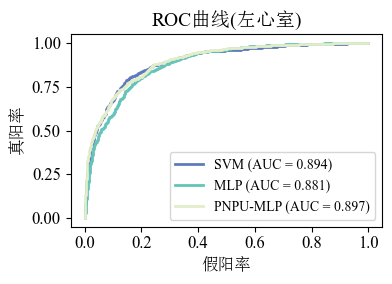

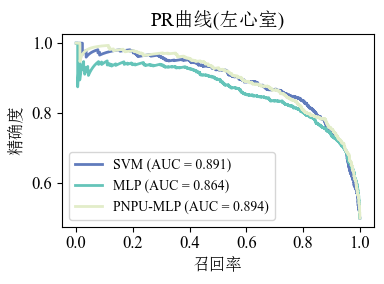

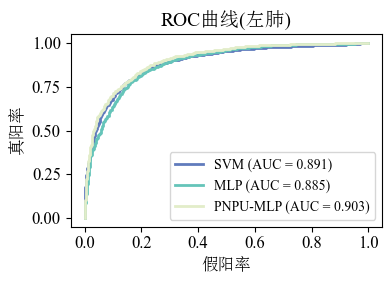

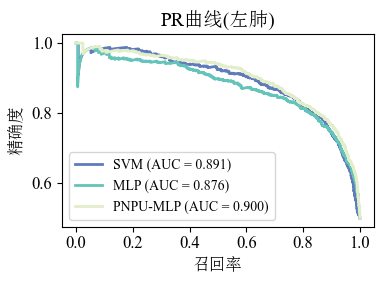

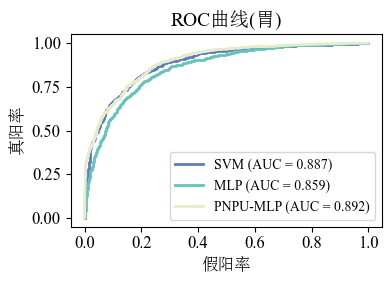

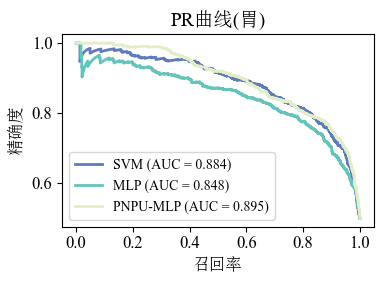

In [162]:
# Human
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import os
from matplotlib import rcParams

# Set the font style
rcParams['font.family'] = ['Times New Roman', 'SimSun']

# Base directory for traditional classifiers
input_folder = '../../classifier/'

if __name__ == "__main__":

    # 加入 PNU-MLP
    model_names = ['SVM', 'MLP', 'PNPU-MLP']
    species = 'human'
    
    # Define a color map for different models
    model_colors = {
        'SVM': '#607BBC', 
        'MLP': '#65c4b9',
        'PNPU-MLP': "#e2edc9"
    }

    tissues = {
        'heart': '左心室',
        'lung': '左肺',
        'stomach': '胃'
    }

    for tissue, tissue_name in tissues.items():
        
        # =============================
        # ROC
        # =============================
        plt.figure(figsize=(4, 3))

        for model_name in model_names:

            if model_name == 'PNPU-MLP':
                # PNU 路径
                roc_file_path = os.path.join(
                    f'./pnu_train_pn_eval_{species}',
                    f'oof_roc_curve_PN_{tissue}.csv'
                )
            else:
                # 传统模型路径
                roc_file_path = os.path.join(
                    input_folder,
                    f'{model_name}/performance/{species}/curve/roc_curve_{tissue}.csv'
                )

            if not os.path.exists(roc_file_path):
                print(f"Missing ROC file: {roc_file_path}")
                continue

            roc_data = pd.read_csv(roc_file_path)
            fpr = roc_data['FPR']
            tpr = roc_data['TPR']
            roc_auc = auc(fpr, tpr)

            plt.plot(
                fpr,
                tpr,
                label=f'{model_name} (AUC = {roc_auc:.3f})',
                color=model_colors.get(model_name),
                linewidth=2
            )

        plt.xlabel('假阳率', fontsize=12)
        plt.ylabel('真阳率', fontsize=12)
        plt.title(f'ROC曲线({tissue_name})', fontsize=14)
        plt.legend(loc='lower right', frameon=True, fontsize=10)
        plt.tight_layout()

        os.makedirs(species, exist_ok=True)
        plt.savefig(f'{species}/{tissue}_ROC.svg')
        plt.show()

        # =============================
        # PR
        # =============================
        plt.figure(figsize=(4, 3))

        for model_name in model_names:

            if model_name == 'PNPU-MLP':
                pr_file_path = os.path.join(
                    f'./pnu_train_pn_eval_{species}',
                    f'oof_pr_curve_PN_{tissue}.csv'
                )
            else:
                pr_file_path = os.path.join(
                    input_folder,
                    f'{model_name}/performance/{species}/curve/pr_curve_{tissue}.csv'
                )

            if not os.path.exists(pr_file_path):
                print(f"Missing PR file: {pr_file_path}")
                continue

            pr_data = pd.read_csv(pr_file_path)
            recall = pr_data['Recall']
            precision = pr_data['Precision']
            pr_auc = auc(recall, precision)

            plt.plot(
                recall,
                precision,
                label=f'{model_name} (AUC = {pr_auc:.3f})',
                color=model_colors.get(model_name),
                linewidth=2
            )

        plt.xlabel('召回率', fontsize=12)
        plt.ylabel('精确度', fontsize=12)
        plt.title(f'PR曲线({tissue_name})', fontsize=14)
        plt.legend(loc='lower left', frameon=True, fontsize=10)
        plt.tight_layout()

        plt.savefig(f'{species}/{tissue}_PR.svg')
        plt.show()


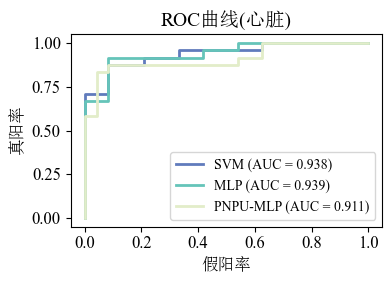

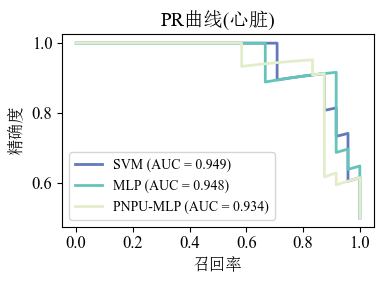

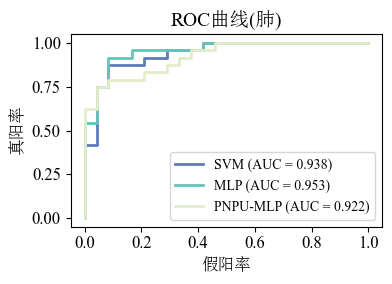

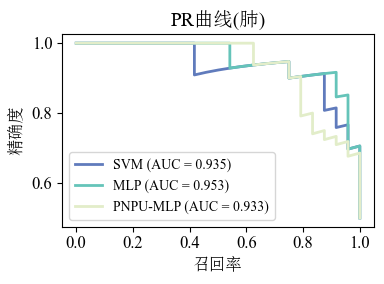

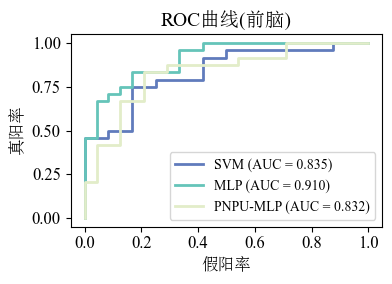

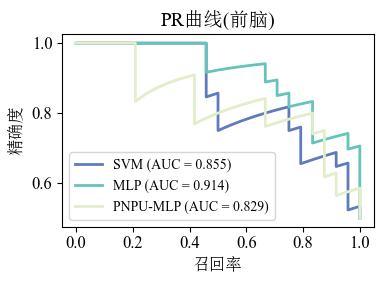

In [163]:
# Mouse
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import os
from matplotlib import rcParams

# Set the font style
rcParams['font.family'] = ['Times New Roman', 'SimSun']

# Base directory for traditional classifiers
input_folder = '../../classifier/'

if __name__ == "__main__":

    # 加入 PNU-MLP
    model_names = ['SVM', 'MLP', 'PNPU-MLP']
    species = 'mouse'
    
    # Define a color map for different models
    model_colors = {
        'SVM': '#607BBC', 
        'MLP': '#65c4b9',
        'PNPU-MLP': "#e2edc9"
    }

    tissues = {
        'heart': '心脏',
        'lung': '肺',
        'brain': '前脑'
    }

    for tissue, tissue_name in tissues.items():
        
        # =============================
        # ROC
        # =============================
        plt.figure(figsize=(4, 3))

        for model_name in model_names:

            if model_name == 'PNPU-MLP':
                # PNU 路径
                roc_file_path = os.path.join(
                    f'./pnu_train_pn_eval_{species}_U1000_epSubsample',
                    f'oof_roc_curve_PN_{tissue}.csv'
                )
            else:
                # 传统模型路径
                roc_file_path = os.path.join(
                    input_folder,
                    f'{model_name}/performance/{species}/curve/roc_curve_{tissue}.csv'
                )

            if not os.path.exists(roc_file_path):
                print(f"Missing ROC file: {roc_file_path}")
                continue

            roc_data = pd.read_csv(roc_file_path)
            fpr = roc_data['FPR']
            tpr = roc_data['TPR']
            roc_auc = auc(fpr, tpr)

            plt.plot(
                fpr,
                tpr,
                label=f'{model_name} (AUC = {roc_auc:.3f})',
                color=model_colors.get(model_name),
                linewidth=2
            )

        plt.xlabel('假阳率', fontsize=12)
        plt.ylabel('真阳率', fontsize=12)
        plt.title(f'ROC曲线({tissue_name})', fontsize=14)
        plt.legend(loc='lower right', frameon=True, fontsize=10)
        plt.tight_layout()

        os.makedirs(species, exist_ok=True)
        plt.savefig(f'{species}/{tissue}_ROC.svg')
        plt.show()

        # =============================
        # PR
        # =============================
        plt.figure(figsize=(4, 3))

        for model_name in model_names:

            if model_name == 'PNPU-MLP':
                pr_file_path = os.path.join(
                    f'./pnu_train_pn_eval_{species}_U1000_epSubsample',
                    f'oof_pr_curve_PN_{tissue}.csv'
                )
            else:
                pr_file_path = os.path.join(
                    input_folder,
                    f'{model_name}/performance/{species}/curve/pr_curve_{tissue}.csv'
                )

            if not os.path.exists(pr_file_path):
                print(f"Missing PR file: {pr_file_path}")
                continue

            pr_data = pd.read_csv(pr_file_path)
            recall = pr_data['Recall']
            precision = pr_data['Precision']
            pr_auc = auc(recall, precision)

            plt.plot(
                recall,
                precision,
                label=f'{model_name} (AUC = {pr_auc:.3f})',
                color=model_colors.get(model_name),
                linewidth=2
            )

        plt.xlabel('召回率', fontsize=12)
        plt.ylabel('精确度', fontsize=12)
        plt.title(f'PR曲线({tissue_name})', fontsize=14)
        plt.legend(loc='lower left', frameon=True, fontsize=10)
        plt.tight_layout()

        plt.savefig(f'{species}/{tissue}_PR.svg')
        plt.show()


ES

In [3]:
import pandas as pd
from gseapy import gseaplot
import gseapy as gp

for species in ['human', 'mouse']:
	model_name = 'PNPU-MLP'
	ess = pd.read_csv(f"../../data/benchmark/{species}/ess_lnc.csv")
	ess.head()
	gene_sets = {'Essential LncRNA':ess['lncRNA_id']}

	if species == 'human':
		tissue_dict={'heart':'左心室','lung':'左肺','stomach':'胃'}
	else:
		tissue_dict={'heart':'心脏','lung':'肺','brain':'前脑'}

	for tissue in tissue_dict.keys():

		tissue_name = tissue_dict[tissue]
		prediction = pd.read_csv(f"./final_train_score_{species}/final_scores_all_nodes_PNU_{tissue}.csv")
		prediction = prediction[['lncRNA_id','score_final']]

		rnk = prediction

		pre_res = gp.prerank(rnk=rnk,
							gene_sets=gene_sets,
							threads=4,
							min_size=5,
							max_size=4000,
							permutation_num=1000, # reduce number to speed up testing
							outdir=None, # don't write to disk
							seed=6,
							verbose=True, # see what's going on behind the scenes
							)

		es_df = pd.DataFrame({
			"lncRNA_id": pre_res.ranking.index,
			"ES_score": pre_res.results['Essential LncRNA']["RES"]
		})
		results = pd.merge(es_df, prediction, on='lncRNA_id', how='inner')
		results['label'] = results['lncRNA_id'].isin(ess['lncRNA_id']).astype(int)
		results.to_csv(f"{species}/res_{model_name}_{tissue}.csv", index=False)
		gsea_res = pre_res.res2d
		gsea_res.to_csv(f"{species}/gsea_{model_name}_{tissue}.csv", index=False)

		terms = pre_res.res2d.Term
		fig = gseaplot(
			term=f"{model_name}({tissue_name})",
			**pre_res.results[terms[0]],
			color="green",
			figsize=(4, 3),
			ofname=f"{species}/{model_name}_{tissue}.svg",
			rank_metric=None
		)


2026-02-25 14:29:29,807 [WARNING] Duplicated values found in preranked stats: 2.65% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-25 14:29:29,808 [INFO] Parsing data files for GSEA.............................
2026-02-25 14:29:29,856 [INFO] 0000 gene_sets have been filtered out when max_size=4000 and min_size=5
2026-02-25 14:29:29,857 [INFO] 0001 gene_sets used for further statistical testing.....
2026-02-25 14:29:29,858 [INFO] Start to run GSEA...Might take a while..................
2026-02-25 14:29:31,319 [INFO] Congratulations. GSEApy runs successfully................

2026-02-25 14:29:31,682 [WARNING] Duplicated values found in preranked stats: 1.31% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-25 14:29:31,683 [INFO] Parsing data files for GSEA.............................
2026-02-25 14:29:31,731 [INFO] 0000 gene_sets have been filtered out when max_size=4000 and min_size=5
20

In [15]:
import numpy as np
import pandas as pd

SPECIE = 'human'
TISSUE = 'heart'

PRED_PNU_CSV = f"./final_train_score_{SPECIE}/final_scores_all_nodes_PNU_{TISSUE}.csv"
ID_COL = "lncRNA_id"
SCORE_COL = "score_final"
RECALL = 0.8

# ESS_CSV：只有一列 lncRNA_id，有表头
ESS_CSV = f"../../data/benchmark/{SPECIE}/ess_lnc.csv"

# =============================
# Load PNU predictions
# =============================
pred_df = pd.read_csv(PRED_PNU_CSV)

missing_cols = [c for c in [ID_COL, SCORE_COL] if c not in pred_df.columns]
if missing_cols:
    raise ValueError(f"PRED_PNU_CSV missing columns: {missing_cols}. "
                     f"Found columns: {list(pred_df.columns)}")

pred_df = pred_df[[ID_COL, SCORE_COL]].copy()
pred_df[ID_COL] = pred_df[ID_COL].astype(str).str.strip()
pred_df[SCORE_COL] = pd.to_numeric(pred_df[SCORE_COL], errors="coerce")
pred_df = pred_df.dropna(subset=[ID_COL, SCORE_COL])

# de-dup by max score per id
pred_df = pred_df.groupby(ID_COL, as_index=False)[SCORE_COL].max()

# sort descending
pred_df = pred_df.sort_values(SCORE_COL, ascending=False).reset_index(drop=True)

universe_ids = set(pred_df[ID_COL].tolist())
N = len(universe_ids)

# =============================
# Load known essentials
# =============================
ess_df = pd.read_csv(ESS_CSV)  # has header
if ID_COL not in ess_df.columns:
    # in case the header name isn't exactly lncRNA_id
    if ess_df.shape[1] == 1:
        ess_df.columns = [ID_COL]
    else:
        raise ValueError(f"ESS_CSV does not contain column '{ID_COL}'. "
                         f"Found columns: {list(ess_df.columns)}")

ess_df[ID_COL] = ess_df[ID_COL].astype(str).str.strip()
ess_df = ess_df.dropna(subset=[ID_COL])

ess_ids_all = set(ess_df[ID_COL].tolist())
ess_ids = ess_ids_all & universe_ids   # restrict to comparable universe
M = len(ess_ids)

if M == 0:
    raise ValueError("No essential IDs overlap with prediction universe. "
                     "Check ID formats between PRED_PNU_CSV and ESS_CSV.")

target_hits = int(np.ceil(RECALL * M))

# =============================
# Find minimal K to reach recall
# =============================
is_hit = pred_df[ID_COL].isin(ess_ids).to_numpy(dtype=np.int8)
cum_hits = np.cumsum(is_hit)

# first index where cum_hits >= target_hits
idx = np.searchsorted(cum_hits, target_hits, side="left")

if idx >= len(cum_hits):
    # cannot reach target recall
    achieved = cum_hits[-1] / M
    print("========== Recall@K Summary ==========")
    print(f"SPECIE={SPECIE}, TISSUE={TISSUE}")
    print(f"Universe size (N)                : {N}")
    print(f"Essentials in universe (M)       : {M}")
    print(f"Target recall                    : {RECALL:.2f}")
    print(f"Target hits (ceil)               : {target_hits}")
    print(f"Max hits achievable              : {cum_hits[-1]}")
    print(f"Achieved max recall              : {achieved:.4f}")
    print("WARNING: Cannot reach target recall with this ranked list.")
else:
    K_needed = idx + 1  # because idx is 0-based position
    recall_at_K = cum_hits[idx] / M
    precision_at_K = cum_hits[idx] / K_needed

    print("========== Recall@K Summary ==========")
    print(f"SPECIE={SPECIE}, TISSUE={TISSUE}")
    print(f"Universe size (N)                : {N}")
    print(f"Essentials in universe (M)       : {M}")
    print(f"Target recall                    : {RECALL:.2f}")
    print(f"Target hits (ceil)               : {target_hits}")
    print(f"Minimal K to reach target recall : {K_needed}")
    print(f"Recall@K                         : {recall_at_K:.4f}")
    print(f"Precision@K                      : {precision_at_K:.4f}")


========== Recall@K Summary ==========
SPECIE=human, TISSUE=heart
Universe size (N)                : 35332
Essentials in universe (M)       : 1372
Target recall                    : 0.80
Target hits (ceil)               : 1098
Minimal K to reach target recall : 11485
Recall@K                         : 0.8003
Precision@K                      : 0.0956
